In [1]:
import pandas as pd
df = pd.read_csv('paired_codes.csv')
df['java_code_len'] = df['java_code'].apply(len)

In [2]:
df['len_bin'] = pd.qcut(df['java_code_len'], q=20, labels=False, duplicates='drop')
stratified_sample = df.groupby('len_bin').apply(lambda x: x.sample(n=min(len(x), 50), random_state=42)).reset_index(drop=True)

/tmp/ipykernel_42848/3687413184.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = df.groupby('len_bin').apply(lambda x: x.sample(n=min(len(x), 50), random_state=42)).reset_index(drop=True)


In [3]:
original_lens = df['java_code'].str.len()
sample_lens = stratified_sample['java_code'].str.len()

K-S Statistic: 0.0182
P-value: 0.9177


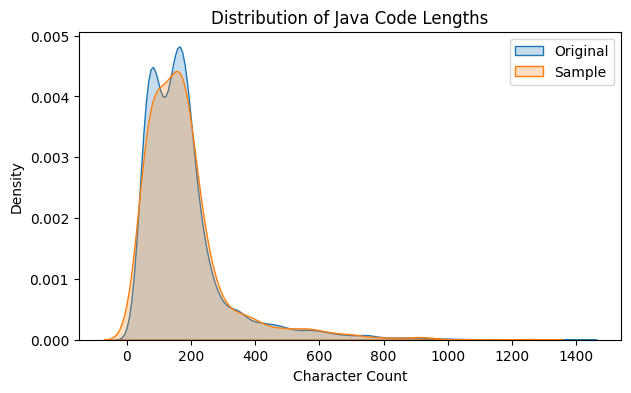

In [4]:

import seaborn as sns
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt

stat, p_value = ks_2samp(original_lens, sample_lens)
print(f"K-S Statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# 3. Visualize the overlap
plt.figure(figsize=(7, 4))
sns.kdeplot(original_lens, label='Original', fill=True)
sns.kdeplot(sample_lens, label='Sample', fill=True)
plt.title('Distribution of Java Code Lengths')
plt.xlabel('Character Count')
plt.legend()
plt.show()

In [6]:
stratified_sample[['id', 'java_code', 'cs_code']].to_csv('paired_codes_sampled.csv', index=False)